# Projeto Final (Parte A)

## Migração do Projeto Anterior para Spark

**Disciplina:** [12517] Arquitetura de Grandes Volumes de Dados

**Membros:**
- Giulia Monteiro Garrido (RA: 24010281)
- Thomaz Dacorso (RA: 24012310)
- Victor França (RA: 24010801)
- Vitor Furuta (RA: 24008775)

---

Este projeto migra a pipeline Lambda desenvolvida na Atividade 3 para uma implementação em **Apache Spark (PySpark)**, mantendo as mesmas três camadas: **Lote**, **Velocidade** e **Apresentação**.

O dataset utilizado é o Amazon Sales Dataset (`aliiihussain/amazon-sales-dataset`), com 50.000 registros de pedidos. A camada de velocidade continua usando o último mês do dataset (2023-12) como dados de entrada via micro-lotes (arquivos CSV pequenos), enquanto os demais meses formam a camada de lote particionada por ano/mês.

**Organização do notebook:**
1. Setup e dados
2. Camada de Lote (Spark `read`)
3. Camada de Velocidade (Spark `readStream`)
4. Camada de Apresentação (consultas combinadas)

---
## 1. Setup e Preparação dos Dados

### 1.1 Imports e SparkSession

Inicializamos a `SparkSession` em modo local (`local[*]`) com 4 GB de memória para o driver. O nível de log é reduzido para `ERROR` para evitar mensagens desnecessárias durante a execução.

In [67]:
import os
import shutil
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField,
    IntegerType, DoubleType, StringType, DateType
)

In [68]:
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("ProjetoFinal_ParteA")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark versão: {spark.version}")

Spark versão: 4.0.2


### 1.2 Download e Particionamento dos Dados

Reutilizamos a lógica de preparação da Atividade 3: baixamos o dataset via `kagglehub`, aplicamos as mesmas regras de quarentena, separamos o último mês (2023-12) para a camada de velocidade e gravamos o lote em `data/<ano>/<mes>/data.csv`.

Os micro-lotes da camada de velocidade são gerados a partir dos dados de 2023-12, divididos em arquivos de **~70 linhas cada** (critério: aproximadamente 3% do tamanho de uma partição mensal, que tem em média ~2.080 linhas). Esse tamanho simula chegada incremental de dados sem sobrecarregar o processamento.

In [69]:
import kagglehub

path = kagglehub.dataset_download("aliiihussain/amazon-sales-dataset")
print("Caminho dos arquivos:", path)

name_files = os.listdir(path)
df = pd.read_csv(os.path.join(path, name_files[0]))
df["order_date"] = pd.to_datetime(df["order_date"])
print(f"Registros carregados: {len(df)}")

Using Colab cache for faster access to the 'amazon-sales-dataset' dataset.
Caminho dos arquivos: /kaggle/input/amazon-sales-dataset
Registros carregados: 50000


In [70]:
# --- Quarentena (mesmas regras da Atividade 3) ---
def validar_linha(row):
    if row.isnull().any():
        return "campo_nulo"
    if row["price"] <= 0 or row["total_revenue"] <= 0 or row["discounted_price"] <= 0:
        return "valor_financeiro_invalido"
    if row["quantity_sold"] < 1:
        return "quantidade_invalida"
    if not (1.0 <= row["rating"] <= 5.0):
        return "rating_fora_do_intervalo"
    if not (0 <= row["discount_percent"] <= 100):
        return "desconto_invalido"
    return None

motivos = df.apply(validar_linha, axis=1)
df_valido = df[motivos.isna()].copy()
df_quarentena = df[~motivos.isna()].copy()
df_quarentena["motivo_quarentena"] = motivos[~motivos.isna()]

print(f"Válidos: {len(df_valido)} | Quarentena: {len(df_quarentena)}")

Válidos: 50000 | Quarentena: 0


In [71]:
# --- Separação lote / stream ---
ultimo_mes = df_valido["order_date"].max().to_period("M")
DATA_CORTE = str(ultimo_mes)  # ex: '2023-12'
print(f"Mês reservado para Camada de Velocidade: {DATA_CORTE}")

mask_stream = df_valido["order_date"].dt.to_period("M") == ultimo_mes
df_stream = df_valido[mask_stream].copy()
df_lote   = df_valido[~mask_stream].copy()

print(f"Lote: {len(df_lote)} linhas | Stream: {len(df_stream)} linhas")

# --- Partições de lote em data/<ano>/<mes>/data.csv ---
if os.path.exists("data"):
    shutil.rmtree("data")

years_lote  = sorted(df_lote["order_date"].dt.year.unique())
months_lote = sorted(df_lote["order_date"].dt.month.unique())

for year in years_lote:
    for month in months_lote:
        df_month = df_lote[
            (df_lote["order_date"].dt.year == year) &
            (df_lote["order_date"].dt.month == month)
        ]
        if df_month.empty:
            continue
        folder = f"data/{year}/{month}"
        os.makedirs(folder, exist_ok=True)
        df_month.to_csv(f"{folder}/data.csv", index=False)

print(f"Partições gravadas em data/ ({len(df_lote)} linhas)")

Mês reservado para Camada de Velocidade: 2023-12
Lote: 47937 linhas | Stream: 2063 linhas
Partições gravadas em data/ (47937 linhas)


In [72]:
# --- Geração dos micro-lotes para a Camada de Velocidade ---
#
# Critério de tamanho: cada partição mensal do lote tem ~2.080 linhas.
# Um micro-lote de 70 linhas representa ~3% de uma partição — pequeno
# o suficiente para simular chegada incremental, grande o suficiente
# para o Spark detectar e processar sem latência excessiva.

MICROBATCH_SIZE = 70

if os.path.exists("dados_novos"):
    shutil.rmtree("dados_novos")
os.makedirs("dados_novos", exist_ok=True)

df_stream_reset = df_stream.reset_index(drop=True)
n_batches = 0
for start in range(0, len(df_stream_reset), MICROBATCH_SIZE):
    chunk = df_stream_reset.iloc[start : start + MICROBATCH_SIZE]
    chunk.to_csv(f"dados_novos/batch_{n_batches:04d}.csv", index=False)
    n_batches += 1

print(f"{n_batches} micro-lotes gerados (~{MICROBATCH_SIZE} linhas cada) em dados_novos/")

30 micro-lotes gerados (~70 linhas cada) em dados_novos/


---
## 2. Camada de Lote

A leitura em lote usa `spark.read` apontando para a pasta `data/`, que contém as partições por ano/mês. O Spark lê todos os arquivos de uma vez, montando um único DataFrame distribuído (`sdf_lote`).

A partir dele construímos as mesmas **6 vistas de lote** da Atividade 3, agora via agregações Spark.

### 2.1 Leitura das Partições

In [73]:
# Schema explícito — recomendado para evitar inferência lenta
# Referência: https://spark.apache.org/docs/latest/api/python/reference/pyspark.sql/data_types.html

schema_lote = StructType([
    StructField("order_id",         IntegerType(), True),
    StructField("order_date",        StringType(),  True),  # lido como string, convertido abaixo
    StructField("product_id",        IntegerType(), True),
    StructField("product_category",  StringType(),  True),
    StructField("price",             DoubleType(),  True),
    StructField("discount_percent",  IntegerType(), True),
    StructField("quantity_sold",      IntegerType(), True),
    StructField("customer_region",   StringType(),  True),
    StructField("payment_method",    StringType(),  True),
    StructField("rating",            DoubleType(),  True),
    StructField("review_count",      IntegerType(), True),
    StructField("discounted_price",  DoubleType(),  True),
    StructField("total_revenue",     DoubleType(),  True),
])

In [74]:
sdf_lote = (
    spark.read
    .option("header", True)
    .option("recursiveFileLookup", "true")
    .schema(schema_lote)
    .csv("data/")           # aponta para toda a pasta de partições
    .withColumn("order_date", F.to_date("order_date"))
)

print(f"Registros no lote: {sdf_lote.count()}")
sdf_lote.limit(5).toPandas()

Registros no lote: 47937


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,32,2023-07-15,2432,Sports,394.76,10,3,North America,UPI,3.7,382,355.28,1065.84
1,41,2023-07-17,2571,Books,40.47,15,1,Middle East,Credit Card,3.7,418,34.40,34.40
2,42,2023-07-21,4885,Books,135.00,30,5,Europe,Cash on Delivery,3.9,469,94.50,472.50
3,57,2023-07-19,4304,Fashion,150.09,10,4,Europe,Cash on Delivery,2.3,363,135.08,540.32
4,67,2023-07-16,4991,Home & Kitchen,53.92,15,1,North America,UPI,2.1,286,45.83,45.83


### 2.2 Construção das Vistas de Lote

Cada vista é calculada como uma agregação Spark e salva em `vistas_lote/` como CSV — mesma estrutura de saída da Atividade 3, garantindo compatibilidade com a camada de apresentação.

In [75]:
VISTAS_DIR = "vistas_lote"
os.makedirs(VISTAS_DIR, exist_ok=True)

# --- Vista 1: Receita por Mês ---
vista_receita_mes = (
    sdf_lote
    .withColumn("ano_mes", F.date_format("order_date", "yyyy-MM"))
    .groupBy("ano_mes")
    .agg(F.round(F.sum("total_revenue"), 2).alias("receita_total"))
    .orderBy("ano_mes")
)

# --- Vista 2: Vendas por Categoria ---
vista_categoria = (
    sdf_lote
    .groupBy("product_category")
    .agg(
        F.count("order_id").alias("total_vendas"),
        F.round(F.sum("total_revenue"), 2).alias("receita_total"),
        F.sum("price").alias("soma_preco"),        # mantido para média ponderada na combinação
        F.sum("rating").alias("soma_rating"),      # mantido para média ponderada na combinação
        F.round(F.avg("price"), 2).alias("preco_medio"),
        F.round(F.avg("rating"), 2).alias("rating_medio"),
    )
)

# --- Vista 3: Vendas por Região ---
vista_regiao = (
    sdf_lote
    .groupBy("customer_region")
    .agg(
        F.count("order_id").alias("total_vendas"),
        F.round(F.sum("total_revenue"), 2).alias("receita_total"),
        F.round(F.avg("total_revenue"), 2).alias("receita_media"),
    )
)

# --- Vista 4: Vendas por Método de Pagamento ---
vista_pagamento = (
    sdf_lote
    .groupBy("payment_method")
    .agg(
        F.count("order_id").alias("total_vendas"),
        F.round(F.sum("total_revenue"), 2).alias("receita_total"),
    )
)

# --- Vista 5: Desconto por Categoria ---
vista_desconto = (
    sdf_lote
    .groupBy("product_category")
    .agg(
        F.count("order_id").alias("total_vendas"),
        F.round(F.avg("discount_percent"), 2).alias("desconto_medio"),
        F.round(F.avg("discounted_price"), 2).alias("preco_desc_medio"),
        F.round(F.avg("quantity_sold"), 2).alias("qtd_media"),
    )
)

# --- Vista 6: Vendas por Dia ---
vista_dia = (
    sdf_lote
    .groupBy("order_date")
    .agg(
        F.count("order_id").alias("total_vendas"),
        F.round(F.sum("total_revenue"), 2).alias("receita_total"),
    )
    .withColumnRenamed("order_date", "data")
    .orderBy("data")
)

print("Vistas de lote calculadas.")

Vistas de lote calculadas.


In [76]:
# Persistência: salva cada vista como CSV único via toPandas()

def salvar_vista(sdf, nome_arquivo):
    caminho = os.path.join(VISTAS_DIR, nome_arquivo)
    sdf.toPandas().to_csv(caminho, index=False)
    print(f"  {nome_arquivo} salvo.")

print("Salvando vistas de lote:")
salvar_vista(vista_receita_mes, "receita_por_mes.csv")
salvar_vista(vista_categoria,   "vendas_por_categoria.csv")
salvar_vista(vista_regiao,      "vendas_por_regiao.csv")
salvar_vista(vista_pagamento,   "vendas_por_pagamento.csv")
salvar_vista(vista_desconto,    "desconto_por_categoria.csv")
salvar_vista(vista_dia,         "vendas_por_dia.csv")

print("\nTodas as vistas de lote salvas em vistas_lote/")
# Verificação: confirma que os CSVs de lote têm dados
print("\nVerificação dos CSVs de lote:")
for arq in os.listdir(VISTAS_DIR):
    caminho = os.path.join(VISTAS_DIR, arq)
    df_check = pd.read_csv(caminho)
    status = f"OK ({len(df_check)} linhas)" if len(df_check) > 0 else "⚠️ VAZIO!"
    print(f"  {arq}: {status}")

Salvando vistas de lote:
  receita_por_mes.csv salvo.
  vendas_por_categoria.csv salvo.
  vendas_por_regiao.csv salvo.
  vendas_por_pagamento.csv salvo.
  desconto_por_categoria.csv salvo.
  vendas_por_dia.csv salvo.

Todas as vistas de lote salvas em vistas_lote/

Verificação dos CSVs de lote:
  receita_por_mes.csv: OK (23 linhas)
  vendas_por_regiao.csv: OK (4 linhas)
  vendas_por_categoria.csv: OK (6 linhas)
  vendas_por_dia.csv: OK (699 linhas)
  desconto_por_categoria.csv: OK (6 linhas)
  vendas_por_pagamento.csv: OK (5 linhas)


In [77]:
# Verificação rápida
print("Prévia — Receita por Mês:")
vista_receita_mes.show(5)

print("Prévia — Vendas por Categoria:")
vista_categoria.show(5)

Prévia — Receita por Mês:
+-------+-------------+
|ano_mes|receita_total|
+-------+-------------+
|2022-01|   1419751.89|
|2022-02|   1266714.29|
|2022-03|   1392585.42|
|2022-04|   1371955.83|
|2022-05|   1374779.57|
+-------+-------------+
only showing top 5 rows
Prévia — Vendas por Categoria:
+----------------+------------+-------------+------------------+------------------+-----------+------------+
|product_category|total_vendas|receita_total|        soma_preco|       soma_rating|preco_medio|rating_medio|
+----------------+------------+-------------+------------------+------------------+-----------+------------+
|  Home & Kitchen|        7914|   5237347.26|2006910.0699999998| 23706.00000000003|     253.59|         3.0|
|         Fashion|        8019|    5267720.7|2024558.3600000017|23950.900000000052|     252.47|        2.99|
|          Sports|        7936|   5200931.69|2001278.1700000027|23796.499999999985|     252.18|         3.0|
|     Electronics|        7972|   5246523.09|2010

---
## 3. Camada de Velocidade

A leitura em fluxo usa `spark.readStream` apontando para `dados_novos/`, onde os micro-lotes são gravados como arquivos CSV separados. O Spark Structured Streaming detecta automaticamente novos arquivos e os processa como micro-lotes.

Para cada vista, um processo de escrita com `.writeStream` grava os resultados incrementais em `vistas_tempo_real/`, com `outputMode="update"` para refletir apenas as linhas modificadas a cada micro-lote.

O checkpoint é reiniciado a cada execução desta seção para garantir reprodutibilidade.

### 3.1 Limpeza e Configuração Inicial

In [78]:
# Reinicia checkpoints e pasta de saída para execução limpa
for pasta in ["checkpoints", "vistas_tempo_real"]:
    if os.path.exists(pasta):
        shutil.rmtree(pasta)
    os.makedirs(pasta)

print("Checkpoints e vistas_tempo_real/ reiniciados.")

Checkpoints e vistas_tempo_real/ reiniciados.


### 3.2 Leitura do Stream

In [79]:
# O schema é o mesmo do lote — o Spark precisa de schema explícito para readStream
sdf_fluxo = (
    spark.readStream
    .option("header", True)
    .schema(schema_lote)
    .csv("dados_novos/")    # detecta novos arquivos CSV incrementalmente
    .withColumn("order_date", F.to_date("order_date"))
)

print("Stream source configurado. isStreaming:", sdf_fluxo.isStreaming)

Stream source configurado. isStreaming: True


### 3.3 Definição das Vistas de Tempo Real

As mesmas 6 vistas são definidas sobre o DataFrame de stream. As agregações são idênticas às do lote — a diferença está no uso de `readStream` como fonte e `writeStream` como destino.

In [80]:
TR_DIR = "vistas_tempo_real"

# --- Vista TR 1: Receita por Mês ---
vista_tr_receita_mes = (
    sdf_fluxo
    .withColumn("ano_mes", F.date_format("order_date", "yyyy-MM"))
    .groupBy("ano_mes")
    .agg(F.round(F.sum("total_revenue"), 2).alias("receita_total"))
)

# --- Vista TR 2: Vendas por Categoria ---
vista_tr_categoria = (
    sdf_fluxo
    .groupBy("product_category")
    .agg(
        F.count("order_id").alias("total_vendas"),
        F.round(F.sum("total_revenue"), 2).alias("receita_total"),
        F.sum("price").alias("soma_preco"),
        F.sum("rating").alias("soma_rating"),
        F.round(F.avg("price"), 2).alias("preco_medio"),
        F.round(F.avg("rating"), 2).alias("rating_medio"),
    )
)

# --- Vista TR 3: Vendas por Região ---
vista_tr_regiao = (
    sdf_fluxo
    .groupBy("customer_region")
    .agg(
        F.count("order_id").alias("total_vendas"),
        F.round(F.sum("total_revenue"), 2).alias("receita_total"),
        F.round(F.avg("total_revenue"), 2).alias("receita_media"),
    )
)

# --- Vista TR 4: Vendas por Pagamento ---
vista_tr_pagamento = (
    sdf_fluxo
    .groupBy("payment_method")
    .agg(
        F.count("order_id").alias("total_vendas"),
        F.round(F.sum("total_revenue"), 2).alias("receita_total"),
    )
)

# --- Vista TR 5: Desconto por Categoria ---
vista_tr_desconto = (
    sdf_fluxo
    .groupBy("product_category")
    .agg(
        F.count("order_id").alias("total_vendas"),
        F.round(F.avg("discount_percent"), 2).alias("desconto_medio"),
        F.round(F.avg("discounted_price"), 2).alias("preco_desc_medio"),
        F.round(F.avg("quantity_sold"), 2).alias("qtd_media"),
    )
)

# --- Vista TR 6: Vendas por Dia ---
vista_tr_dia = (
    sdf_fluxo
    .groupBy("order_date")
    .agg(
        F.count("order_id").alias("total_vendas"),
        F.round(F.sum("total_revenue"), 2).alias("receita_total"),
    )
    .withColumnRenamed("order_date", "data")
)

print("Vistas de tempo real definidas.")

Vistas de tempo real definidas.


### 3.4 Inicialização dos Processos de Escrita (writeStream)

Cada vista tem seu próprio processo de escrita com checkpoint independente. O `outputMode='update'`  emite apenas as linhas cujo resultado de agregação mudou a cada micro-lote

In [81]:
def iniciar_stream(vista, nome):
    """Inicia um processo writeStream com outputMode='update' via foreachBatch."""
    def escrever_batch(batch_df, batch_id):
        if not batch_df.isEmpty():
            (batch_df.coalesce(1).write
             .mode("append")
             .option("header", "true")
             .csv(f"{TR_DIR}/{nome}/"))
    return (
        vista.writeStream
        .outputMode("update")
        .foreachBatch(escrever_batch)
        .option("checkpointLocation", f"checkpoints/{nome}/")
        .trigger(once=True)
        .start()
    )
proc_receita_mes = iniciar_stream(vista_tr_receita_mes, "receita_por_mes")
proc_categoria   = iniciar_stream(vista_tr_categoria,   "vendas_por_categoria")
proc_regiao      = iniciar_stream(vista_tr_regiao,      "vendas_por_regiao")
proc_pagamento   = iniciar_stream(vista_tr_pagamento,   "vendas_por_pagamento")
proc_desconto    = iniciar_stream(vista_tr_desconto,    "desconto_por_categoria")
proc_dia         = iniciar_stream(vista_tr_dia,         "vendas_por_dia")
print("Processos de stream iniciados (trigger=once).")

Processos de stream iniciados (trigger=once).


In [82]:
# Aguarda o processamento de todos os micro-lotes disponíveis
print("Aguardando processamento de todos os streams...")
for proc in [proc_receita_mes, proc_categoria, proc_regiao,
             proc_pagamento, proc_desconto, proc_dia]:
    proc.awaitTermination()
print("Todos os streams finalizaram.")

Aguardando processamento de todos os streams...
Todos os streams finalizaram.


In [83]:
# Verifica arquivos gerados (streams já encerrados pelo trigger=once)
for nome in ["receita_por_mes", "vendas_por_categoria", "vendas_por_regiao",
             "vendas_por_pagamento", "desconto_por_categoria", "vendas_por_dia"]:
    pasta = f"{TR_DIR}/{nome}/"
    arquivos = [f for f in os.listdir(pasta) if f.endswith(".csv")] if os.path.exists(pasta) else []
    print(f"  {nome}: {len(arquivos)} arquivo(s)")

  receita_por_mes: 1 arquivo(s)
  vendas_por_categoria: 1 arquivo(s)
  vendas_por_regiao: 1 arquivo(s)
  vendas_por_pagamento: 1 arquivo(s)
  desconto_por_categoria: 1 arquivo(s)
  vendas_por_dia: 1 arquivo(s)


---
## 4. Camada de Apresentação

A camada de apresentação combina as vistas de lote (`vistas_lote/`) com as vistas de tempo real (`vistas_tempo_real/`) para produzir as consultas finais — cobrindo todo o período histórico mais o mês em curso.

O cálculo final é feito em **Pandas**. As funções de consulta seguem a mesma lógica de combinação aditiva (somas e contagens) e média ponderada (preço, rating, desconto) já documentada anteriormente.

Os resultados separados em dados de lote (azul) e dados de tempo real (laranja).

### 4.1 Funções Auxiliares de Leitura das Vistas TR

In [84]:
def ler_vista_tr(nome):
    """
    Lê todos os CSVs gerados pelo writeStream
    para uma vista de tempo real.

    Com 'update', cada micro-lote grava apenas as linhas cujo valor
    de agregação mudou. Para obter o estado final correto, lemos todos
    os arquivos em ordem cronológica e mantemos apenas a última
    ocorrência de cada chave de agrupamento (primeira coluna).
    """
    pasta = os.path.join(TR_DIR, nome)
    if not os.path.exists(pasta):
        return pd.DataFrame()
    csvs = sorted([
        os.path.join(pasta, f)
        for f in os.listdir(pasta)
        if f.endswith(".csv")
    ], key=os.path.getmtime)  # ordem cronológica (mais antigo primeiro)
    if not csvs:
        return pd.DataFrame()
    partes = pd.concat([pd.read_csv(c) for c in csvs], ignore_index=True)
    # A primeira coluna é sempre a chave de agrupamento da vista.
    # Mantemos a última ocorrência (mais recente) de cada chave.
    chave = partes.columns[0]
    partes = partes.drop_duplicates(subset=[chave], keep="last")
    return partes.reset_index(drop=True)

### 4.2 Funções de Consulta Combinada (Lote + Tempo Real)

In [85]:
# por mês, somando receitas. Retorna DataFrame com ano_mes e receita_total.
def consulta_receita_por_mes():
    lote = pd.read_csv("vistas_lote/receita_por_mes.csv")
    tr   = ler_vista_tr("receita_por_mes")
    print(f"  [DEBUG] receita_por_mes — lote: {len(lote)} linhas, TR: {len(tr)} linhas")
    if tr.empty:
        return lote.sort_values("ano_mes").reset_index(drop=True)
    if lote.empty:
        return tr.sort_values("ano_mes").reset_index(drop=True)
    combined = (
        pd.concat([lote, tr], ignore_index=True)
        .groupby("ano_mes", as_index=False)
        .agg(receita_total=("receita_total", "sum"))
        .sort_values("ano_mes")
        .reset_index(drop=True)
    )
    return combined.round(2)

# por categoria, com média ponderada de preço e rating usando soma acumulada.
def consulta_vendas_por_categoria():
    lote = pd.read_csv("vistas_lote/vendas_por_categoria.csv")
    tr   = ler_vista_tr("vendas_por_categoria")
    if tr.empty:
        return lote
    # Média ponderada para preco_medio e rating_medio
    combined = pd.concat([lote, tr], ignore_index=True)
    agg = combined.groupby("product_category", as_index=False).agg(
        total_vendas  =("total_vendas",  "sum"),
        receita_total =("receita_total", "sum"),
        soma_preco    =("soma_preco",    "sum"),
        soma_rating   =("soma_rating",   "sum"),
    )
    agg["preco_medio"]  = (agg["soma_preco"]  / agg["total_vendas"]).round(2)
    agg["rating_medio"] = (agg["soma_rating"] / agg["total_vendas"]).round(2)
    return agg.drop(columns=["soma_preco", "soma_rating"]).round(2)

# por região, recalculando receita média = receita_total / total_vendas.
def consulta_vendas_por_regiao():
    lote = pd.read_csv("vistas_lote/vendas_por_regiao.csv")
    tr   = ler_vista_tr("vendas_por_regiao")
    if tr.empty:
        return lote
    combined = (
        pd.concat([lote, tr], ignore_index=True)
        .groupby("customer_region", as_index=False)
        .agg(total_vendas=("total_vendas", "sum"), receita_total=("receita_total", "sum"))
    )
    combined["receita_media"] = (combined["receita_total"] / combined["total_vendas"]).round(2)
    return combined.round(2)

# por método de pagamento, somando vendas e receita.
def consulta_vendas_por_pagamento():
    lote = pd.read_csv("vistas_lote/vendas_por_pagamento.csv")
    tr   = ler_vista_tr("vendas_por_pagamento")
    if tr.empty:
        return lote
    return (
        pd.concat([lote, tr], ignore_index=True)
        .groupby("payment_method", as_index=False)
        .agg(total_vendas=("total_vendas", "sum"), receita_total=("receita_total", "sum"))
        .round(2)
    )

# por categoria com média ponderada de desconto, preço descontado e quantidade.
def consulta_desconto_por_categoria():
    lote = pd.read_csv("vistas_lote/desconto_por_categoria.csv")
    tr   = ler_vista_tr("desconto_por_categoria")
    if tr.empty:
        return lote
    combined = pd.concat([lote, tr], ignore_index=True)
    agg = combined.groupby("product_category", as_index=False).apply(
        lambda g: pd.Series({
            "total_vendas":    g["total_vendas"].sum(),
            "desconto_medio":  round((g["desconto_medio"]  * g["total_vendas"]).sum() / g["total_vendas"].sum(), 2),
            "preco_desc_medio":round((g["preco_desc_medio"] * g["total_vendas"]).sum() / g["total_vendas"].sum(), 2),
            "qtd_media":       round((g["qtd_media"]        * g["total_vendas"]).sum() / g["total_vendas"].sum(), 2),
        })
    ).reset_index(drop=True)
    return agg


# por dia, somando vendas e receita. Trata renomeação de coluna order_date→data.
def consulta_vendas_por_dia():
    lote = pd.read_csv("vistas_lote/vendas_por_dia.csv")
    tr   = ler_vista_tr("vendas_por_dia")
    print(f"  [DEBUG] vendas_por_dia — lote: {len(lote)} linhas, TR: {len(tr)} linhas")
    # A coluna data pode ser 'data' ou 'order_date' dependendo da saída do stream
    if not tr.empty and "order_date" in tr.columns:
        tr = tr.rename(columns={"order_date": "data"})
    if tr.empty:
        return lote.sort_values("data").reset_index(drop=True)
    if lote.empty:
        return tr.sort_values("data").reset_index(drop=True)
    return (
        pd.concat([lote, tr], ignore_index=True)
        .groupby("data", as_index=False)
        .agg(total_vendas=("total_vendas", "sum"), receita_total=("receita_total", "sum"))
        .sort_values("data")
        .reset_index(drop=True)
        .round(2)
    )

print("Funções de consulta combinada definidas.")

Funções de consulta combinada definidas.


### 4.3 Consultas e Visualizações

Executamos as 6 consultas e geramos os mesmos gráficos da Atividade 3. Os dados do mês de tempo real (2023-12) aparecem em **laranja**, os dados de lote em **azul**.

In [86]:
COR_LOTE = "steelblue"
COR_TR   = "darkorange"

  [DEBUG] receita_por_mes — lote: 23 linhas, TR: 1 linhas


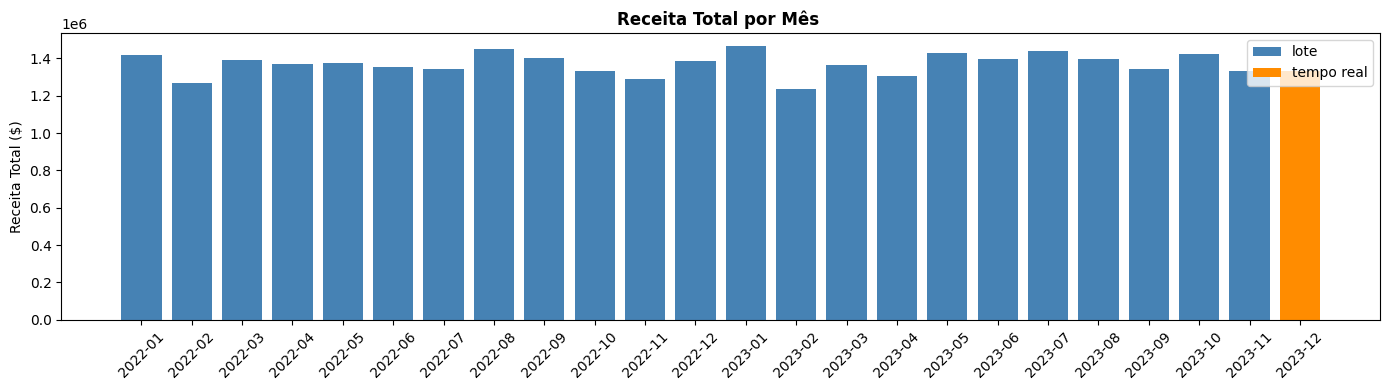

In [87]:
# --- Receita Total por Mês ---
rc = consulta_receita_por_mes()
mask_tr = rc["ano_mes"].astype(str).str.startswith(DATA_CORTE)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(rc.loc[~mask_tr, "ano_mes"], rc.loc[~mask_tr, "receita_total"],
       color=COR_LOTE, label="lote")
ax.bar(rc.loc[mask_tr, "ano_mes"],  rc.loc[mask_tr,  "receita_total"],
       color=COR_TR,   label="tempo real")
ax.set_title("Receita Total por Mês ",
             fontweight="bold")
ax.set_ylabel("Receita Total ($)")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

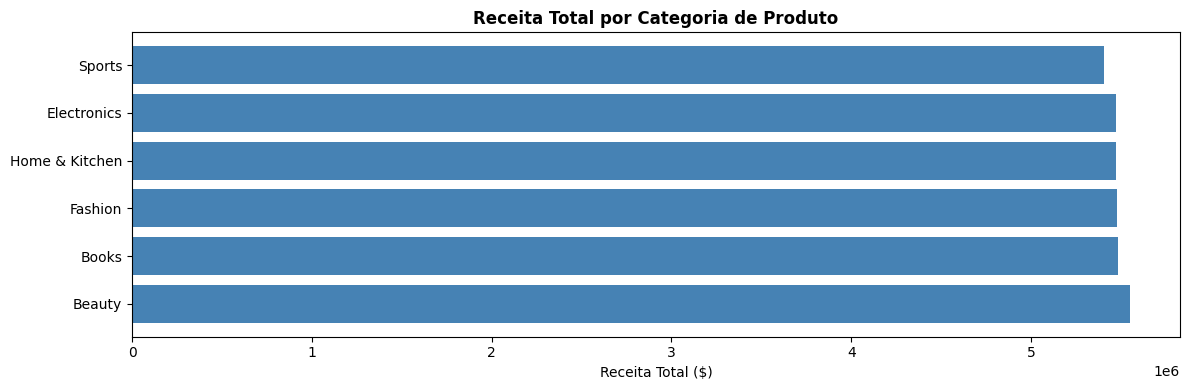

In [88]:
# --- Vendas por Categoria ---
vc = consulta_vendas_por_categoria().sort_values("receita_total", ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.barh(vc["product_category"], vc["receita_total"], color=COR_LOTE)
ax.set_title("Receita Total por Categoria de Produto", fontweight="bold")
ax.set_xlabel("Receita Total ($)")
plt.tight_layout()
plt.show()

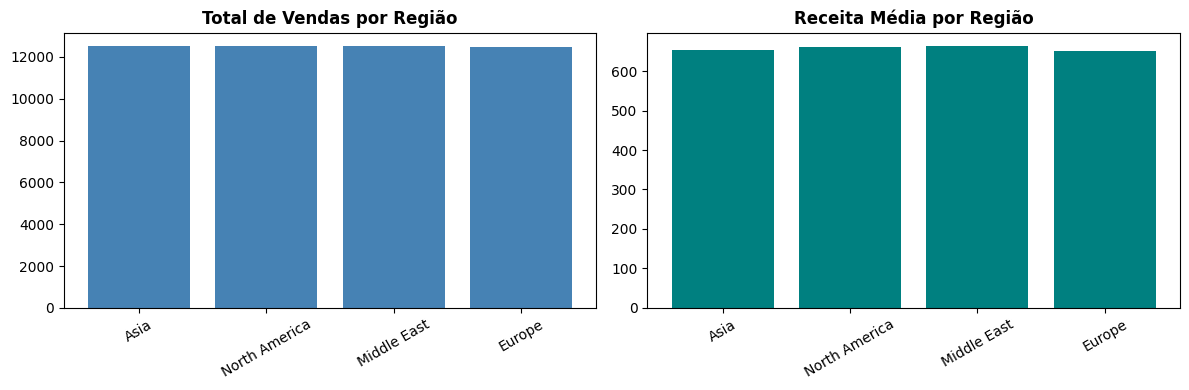

In [89]:
# --- Vendas por Região ---
vr = consulta_vendas_por_regiao().sort_values("total_vendas", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(vr["customer_region"], vr["total_vendas"], color=COR_LOTE)
axes[0].set_title("Total de Vendas por Região", fontweight="bold")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(vr["customer_region"], vr["receita_media"], color="teal")
axes[1].set_title("Receita Média por Região", fontweight="bold")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

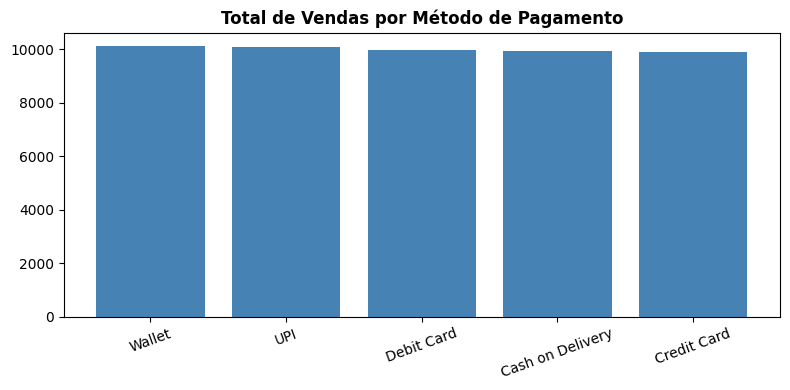

In [90]:
# --- Vendas por Método de Pagamento ---
vp = consulta_vendas_por_pagamento().sort_values("total_vendas", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(vp["payment_method"], vp["total_vendas"], color=COR_LOTE)
ax.set_title("Total de Vendas por Método de Pagamento", fontweight="bold")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6459/2718474483.py:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg = combined.groupby("product_category", as_index=False).apply(


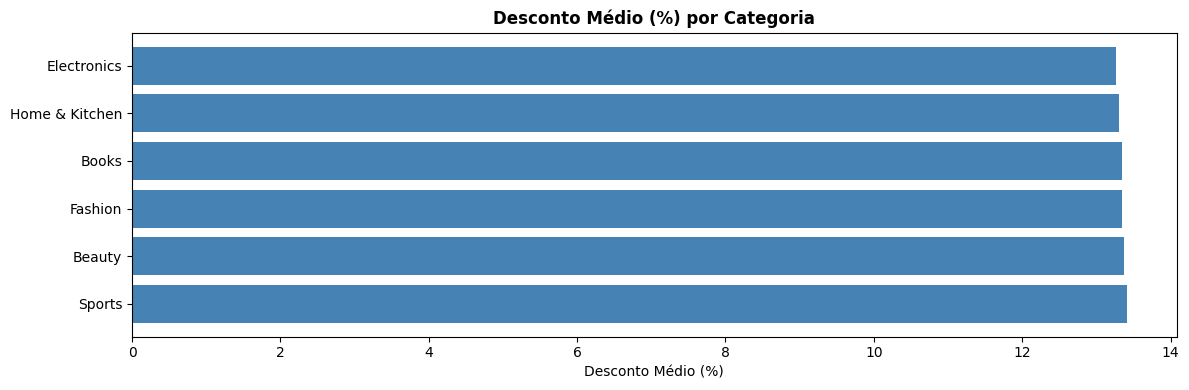

,product_category,total_vendas,desconto_medio,preco_desc_medio,qtd_media
5,Sports,8265.0,13.41,217.96,3.00
0,Beauty,8465.0,13.37,218.68,3.01
3,Fashion,8365.0,13.35,218.65,3.00
1,Books,8327.0,13.34,218.74,3.01
4,Home & Kitchen,8258.0,13.31,220.48,2.99
2,Electronics,8320.0,13.26,218.83,2.99


In [91]:
# --- Desconto por Categoria ---
vd = consulta_desconto_por_categoria().sort_values("desconto_medio", ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.barh(vd["product_category"], vd["desconto_medio"], color=COR_LOTE)
ax.set_title("Desconto Médio (%) por Categoria", fontweight="bold")
ax.set_xlabel("Desconto Médio (%)")
plt.tight_layout()
plt.show()

vd

  [DEBUG] vendas_por_dia — lote: 699 linhas, TR: 31 linhas


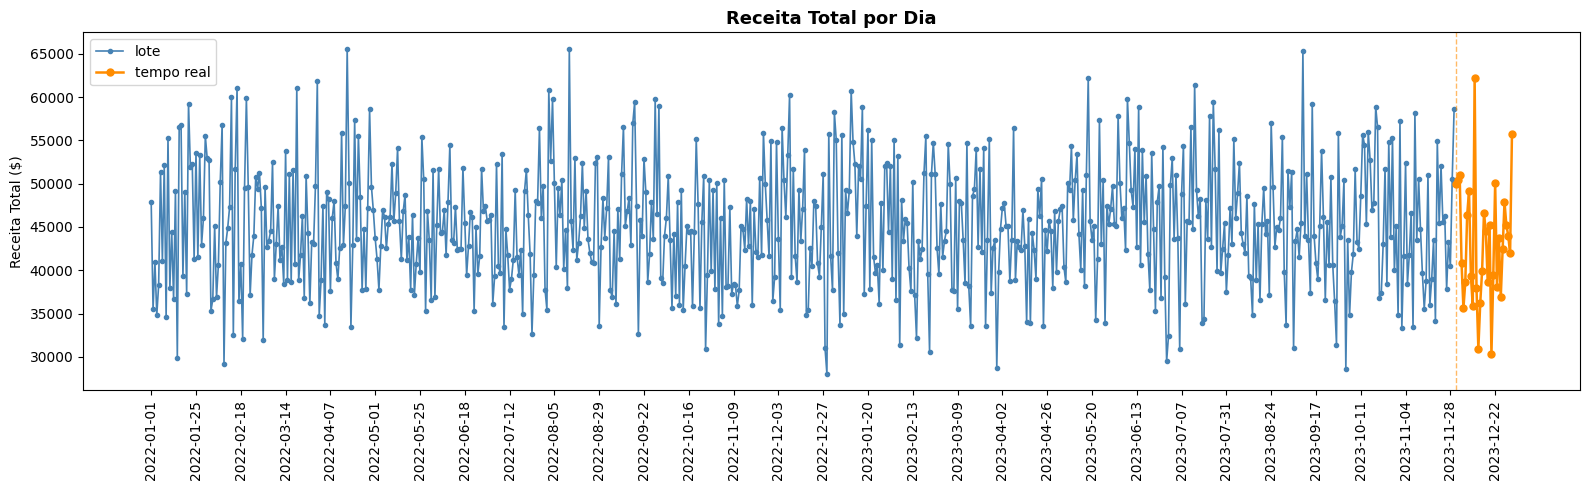

In [92]:
# --- Receita Total por Dia (lote + tempo real) ---
rc_dia = consulta_vendas_por_dia()
rc_dia["data"] = rc_dia["data"].astype(str)

mask_tr_dia = rc_dia["data"].str.startswith(DATA_CORTE)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(
    rc_dia.loc[~mask_tr_dia, "data"],
    rc_dia.loc[~mask_tr_dia, "receita_total"],
    color=COR_LOTE, linewidth=1.2, marker="o", markersize=3, label="lote"
)
ax.plot(
    rc_dia.loc[mask_tr_dia, "data"],
    rc_dia.loc[mask_tr_dia, "receita_total"],
    color=COR_TR, linewidth=1.8, marker="o", markersize=5, label="tempo real"
)
if mask_tr_dia.any():
    primeiro_tr = rc_dia.loc[mask_tr_dia, "data"].iloc[0]
    ax.axvline(x=primeiro_tr, color=COR_TR, linestyle="--", linewidth=1, alpha=0.6)

ax.set_title("Receita Total por Dia",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Receita Total ($)")
ax.tick_params(axis="x", rotation=90)
step = max(1, len(rc_dia) // 30)
ax.set_xticks(range(0, len(rc_dia), step))
ax.set_xticklabels(rc_dia["data"].iloc[::step])
ax.legend()
plt.tight_layout()
plt.show()

---
## Resumo da Migração

| Componente | Atividade 3 | Projeto Final (Parte A) |
|---|---|---|
| **Camada de Lote** | Pandas: loop sobre partições CSV, `pd.concat` | **Spark `read`**: leitura unificada da pasta `data/` com schema explícito |
| **Processamento** | `groupBy` + `agg` em Pandas, parciais + finalização | **Spark `groupBy` + `agg`** distribuídos |
| **Camada de Velocidade** | Thread Python monitorando `fluxo.log` linha a linha | **Spark Structured Streaming `readStream`** com micro-lotes CSV |
| **Saída do stream** | Dicionários em memória + CSVs manuais | **`writeStream` CSV** com checkpoint automático |
| **Camada de Apresentação** | Pandas + matplotlib | **Pandas + matplotlib** (mesmas funções; lê saídas Spark) |
| **Tamanho micro-lote** | — | ~70 linhas (~3% de uma partição mensal) |